In [1]:
# 1) Imports
import warnings
warnings.filterwarnings('ignore')
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, f1_score
from sklearn.utils import class_weight
import joblib

print('Python:', sys.version.splitlines()[0])
print('pandas:', pd.__version__)


Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
pandas: 2.2.3


In [2]:
# 2) Load dataset (looks for datafinish.csv in several locations)
csv_candidates = ['/mnt/data/data_finish.csv', 'data_finish.csv', '/workspace/data_finish.csv']
csv_file = None
for p in csv_candidates:
    if Path(p).exists():
        csv_file = p
        break

if csv_file is None:
    raise FileNotFoundError('datafinish.csv not found. Place the file next to the notebook or adjust csv_candidates.')
print('Loading', csv_file)
df = pd.read_csv(csv_file)
print('Shape:', df.shape)
df.head()

Loading data_finish.csv
Shape: (6308, 15)


,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,station_name,region_name,flood
0,2016-01-01,26.0,34.8,28.6,81.0,NaN,5.8,5.0,280.0,2.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
1,2016-01-02,25.6,33.2,27.0,88.0,1.6,8.7,4.0,290.0,2.0,W,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
2,2016-01-03,24.4,34.9,28.1,80.0,33.8,5.4,4.0,280.0,2.0,SW,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
3,2016-01-04,24.8,33.6,29.2,81.0,NaN,6.6,3.0,200.0,1.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
4,2016-01-05,25.8,33.6,26.7,91.0,NaN,3.2,3.0,180.0,1.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0


In [3]:
# 3) Infer target (same heuristic as before; override TARGET_COLUMN manually if needed)
target_candidate = None
for col in df.columns:
    if df[col].nunique(dropna=True) == 2:
        target_candidate = col
        break
if target_candidate is None:
    for col in df.columns[::-1]:
        if col.lower() not in ('id','index') and df[col].nunique(dropna=True) <= 10:
            target_candidate = col
            break
if target_candidate is None:
    target_candidate = df.columns[-1]
print('Inferred target column:', target_candidate)
TARGET_COLUMN = target_candidate
X = df.drop(columns=[TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].copy()
print('Target value counts:\n', y.value_counts())

Inferred target column: flood
Target value counts:
 flood
0    5832
1     476
Name: count, dtype: int64


In [5]:
# 4) Preprocessing pipelines (numeric & categorical)
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()
print('Numeric cols:', numeric_cols)
print('Categorical cols:', cat_cols)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, cat_cols)
], remainder='drop')

Numeric cols: ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ddd_x', 'ff_avg', 'station_id']
Categorical cols: ['date', 'ddd_car', 'station_name', 'region_name']


In [6]:
# 5) SMOTE / Oversampling (attempt to use imblearn; fallback to RandomOverSampler if available)
try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
    print('imblearn.SMOTE available')
except Exception as e:
    smote_available = False
    print('imblearn not available; SMOTE will not be used. Consider installing imbalanced-learn (pip install imbalanced-learn).')

imblearn.SMOTE available


In [7]:
# 6) Train/test split (before SMOTE we split to avoid data leakage)
X_pre = preprocessor.fit_transform(X)
print('Preprocessed shape:', X_pre.shape)
stratify_arg = y if y.nunique() == 2 else None
X_train, X_test, y_train, y_test = train_test_split(X_pre, y, test_size=0.2, random_state=42, stratify=stratify_arg)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Preprocessed shape: (6308, 1841)
Train: (5046, 1841) Test: (1262, 1841)


In [8]:
# 7) Apply SMOTE to the training set (if available)
from collections import Counter
print('Before resampling:', Counter(y_train))

X_res, y_res = X_train, y_train
if smote_available:
    try:
        sm = SMOTE(random_state=42, n_jobs=-1)
        X_res, y_res = sm.fit_resample(X_train, y_train)
        print('After SMOTE:', Counter(y_res))
    except Exception as e:
        print('SMOTE failed:', e)
else:
    print('SMOTE not applied; training with original data. You can install imbalanced-learn to enable SMOTE.')

Before resampling: Counter({0: 4665, 1: 381})
SMOTE failed: SMOTE.__init__() got an unexpected keyword argument 'n_jobs'


In [9]:
# 8) Build models: RandomForest (with class weights) + Gradient Booster (LightGBM/XGBoost if available, else HistGradientBoosting)
# RandomForest with class_weight='balanced' to penalize minority errors
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42, class_weight='balanced')

# Try LightGBM or XGBoost, else fall back to sklearn's HistGradientBoostingClassifier
gbm = None
gbm_name = None
try:
    import lightgbm as lgb
    gbm = lgb.LGBMClassifier(n_estimators=500, n_jobs=-1, random_state=42)
    gbm_name = 'lightgbm'
    print('Using LightGBM for booster')
except Exception:
    try:
        import xgboost as xgb
        gbm = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=500, n_jobs=-1, random_state=42)
        gbm_name = 'xgboost'
        print('Using XGBoost for booster')
    except Exception:
        gbm = HistGradientBoostingClassifier(max_iter=200, random_state=42)
        gbm_name = 'sklearn_histgb'
        print('Using sklearn.HistGradientBoostingClassifier as booster fallback')

Using LightGBM for booster


In [10]:
# 9) Create a Voting ensemble (soft voting) — will average predicted probabilities
estimators = [('rf', rf), ('gbm', gbm)]
ensemble = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

In [11]:
# 10) Train the ensemble on resampled data (or original if SMOTE not available)
print('Training ensemble...')
ensemble.fit(X_res, y_res)
print('Done training')

Training ensemble...
Done training


In [12]:
# 11) Threshold tuning: find best threshold by maximizing F1 on validation set (using test set here)
# Get predicted probabilities on the test set
probs = ensemble.predict_proba(X_test)[:,1]

# Compute precision-recall and f1 for different thresholds
prec, recall, pr_thresh = precision_recall_curve(y_test, probs)
# For thresholds returned by precision_recall_curve: length = len(prec)-1
f1_scores = 2 * (prec * recall) / (prec + recall + 1e-12)
best_idx = np.argmax(f1_scores)
best_threshold = pr_thresh[best_idx] if len(pr_thresh)>0 else 0.5
print('Best threshold (by max F1):', best_threshold, 'Best F1:', f1_scores[best_idx])

Best threshold (by max F1): 0.07755759863132441 Best F1: 0.3618421052627282


In [13]:
# 12) Evaluation using chosen threshold
y_pred_proba = probs
y_pred_thresh = (y_pred_proba >= best_threshold).astype(int)

print('\nClassification report (thresholded):')
print(classification_report(y_test, y_pred_thresh))

cm = confusion_matrix(y_test, y_pred_thresh)
print('\nConfusion matrix:\n', cm)

if y_test.nunique() == 2:
    try:
        auc = roc_auc_score(y_test, y_pred_proba)
        print('\nROC AUC:', auc)
    except Exception as e:
        print('ROC AUC could not be computed:', e)

# Feature importances if available (RF and LightGBM/XGBoost)
try:
    importances = ensemble.named_estimators_['rf'].feature_importances_
    print('\nRandomForest top 10 feature importances (indices):')
    idx = np.argsort(importances)[-10:][::-1]
    print(idx)
except Exception as e:
    print('Could not extract RF importances:', e)


Classification report (thresholded):
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      1167
           1       0.26      0.58      0.36        95

    accuracy                           0.85      1262
   macro avg       0.61      0.72      0.64      1262
weighted avg       0.91      0.85      0.87      1262


Confusion matrix:
 [[1013  154]
 [  40   55]]

ROC AUC: 0.8077030622829567

RandomForest top 10 feature importances (indices):
[   3    2    4    1    0    7    5    6    8 1837]


In [16]:
# 13) Save ensemble, preprocessor, and threshold
out_path = 'ensemble_pipeline.joblib'
joblib.dump({'ensemble': ensemble, 'preprocessor': preprocessor, 'threshold': best_threshold}, out_path)
print('Saved ensemble + preprocessor + threshold to', out_path)

Saved ensemble + preprocessor + threshold to ensemble_pipeline.joblib


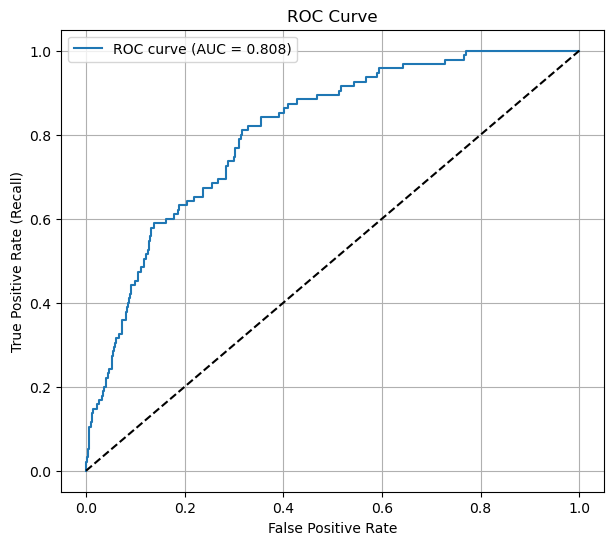

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()
plt.show()

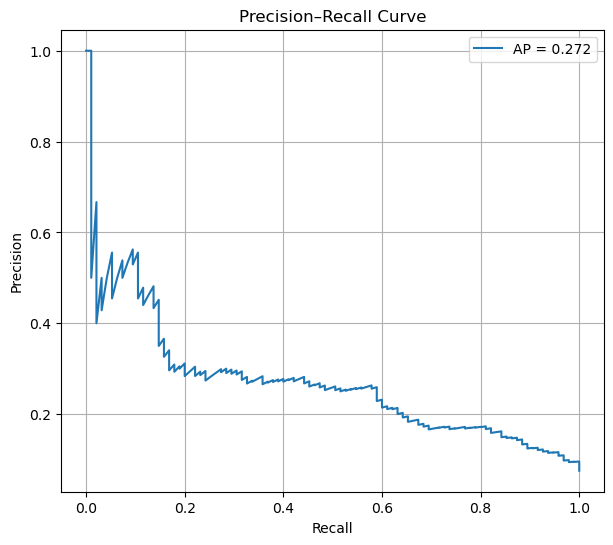

In [18]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_test, probs)
ap = average_precision_score(y_test, probs)

plt.figure(figsize=(7,6))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.legend()
plt.show()


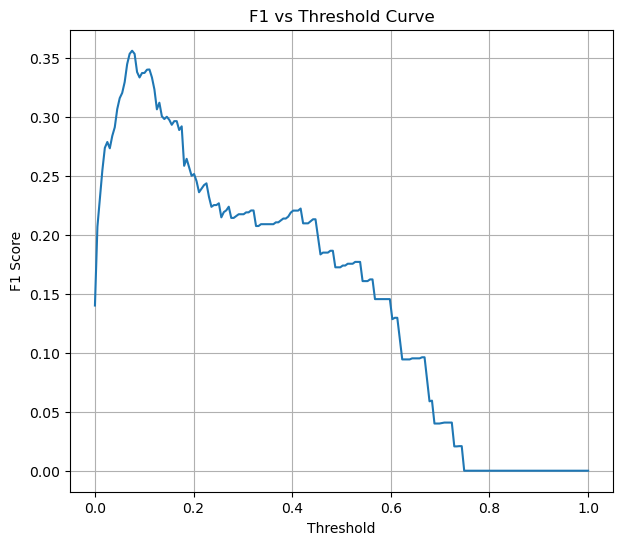

In [19]:
import numpy as np

f1_scores = []
ths = np.linspace(0,1,200)

for t in ths:
    y_pred_t = (probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

plt.figure(figsize=(7,6))
plt.plot(ths, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Threshold Curve")
plt.grid(True)
plt.show()


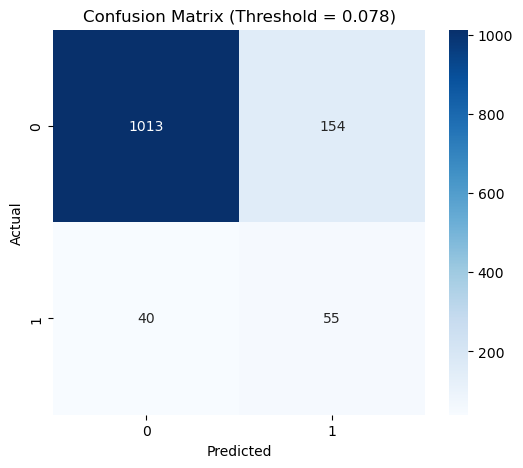

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, (probs >= best_threshold).astype(int))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Threshold = %.3f)" % best_threshold)
plt.show()


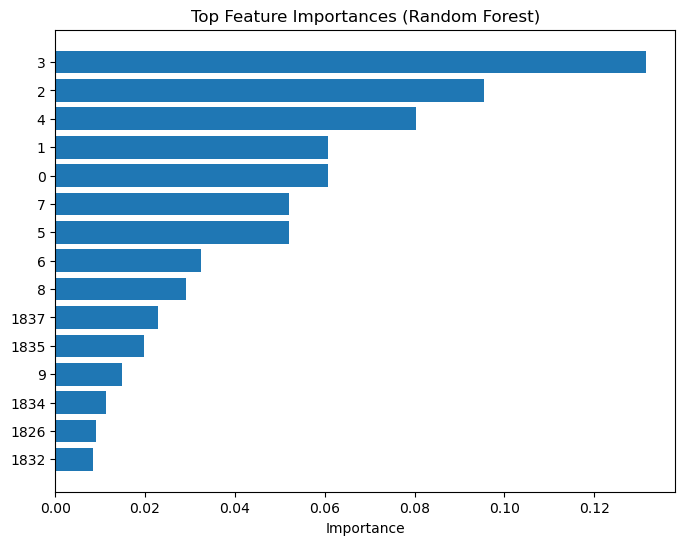

In [21]:
import numpy as np

rf = ensemble.named_estimators_["rf"]
importances = rf.feature_importances_

indices = np.argsort(importances)[-15:][::-1]  # top 15

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices][::-1])
plt.yticks(range(len(indices)), indices[::-1])
plt.xlabel("Importance")
plt.title("Top Feature Importances (Random Forest)")
plt.show()
